# 🎯 Simulation ELO — Artichello

On génère des matchs synthétiques dont les **probabilités de victoire dépendent des ELOs réels** (les *priors*) de chaque joueur.  
L'objectif : vérifier que l'ELO calculé **converge** vers l'ELO réel au fil des matchs.

In [62]:
import random
import math
import datetime
import json
import itertools

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

rng = random.Random(42)

## 1. Priors — ELO « réel » de chaque joueur

On attribue à chaque joueur un ELO vrai qui sert uniquement à **générer les scores** des matchs synthétiques. L'algorithme ELO ne voit jamais ces valeurs — il part de 1000 pour tout le monde.

In [63]:
# Priors : ELO "vrai" par joueur (à adapter si tu as des estimations réelles)
import random

_names = ["Enoal", "Gautier", "Kyrian", "Morgane", "Rossana", "Timothée", "Virgile"]
TRUE_ELO = {name: random.randint(1000, 2500) for name in _names}

PLAYERS = list(TRUE_ELO.keys())
print(f"{len(PLAYERS)} joueurs : {PLAYERS}")
print("ELO moyen :", round(sum(TRUE_ELO.values()) / len(TRUE_ELO)))

7 joueurs : ['Enoal', 'Gautier', 'Kyrian', 'Morgane', 'Rossana', 'Timothée', 'Virgile']
ELO moyen : 1711


## 2. Paramètres ELO (identiques à `elo.ts`)

In [64]:
INITIAL_ELO   = 1000
K_BASE        = 64
K_STREAK      = 128   # K doublé après ≥2 victoires consécutives
STREAK_THRESH = 2
ALPHA         = 1 / 400
MAX_SCORE     = 10   # score max d'une équipe par match

## 3. Génération des matchs synthétiques

### Modèle de score
Pour un match entre l'équipe A et l'équipe B :
- `p_A = sigmoid(ALPHA * (ELO_A - ELO_B))` = probabilité qu'un but tombe côté A
- On tire les `MAX_SCORE` buts selon cette proba → score réaliste

In [65]:
def team_true_elo(players):
    return sum(TRUE_ELO[p] for p in players) / len(players)

def simulate_score(players_a, players_b, max_score=MAX_SCORE):
    """Génère un score basé sur les ELOs réels des équipes."""
    elo_a = team_true_elo(players_a)
    elo_b = team_true_elo(players_b)
    p_a = 1 / (1 + math.pow(10, ALPHA * (elo_b - elo_a)))  # proba but côté A

    # On tire max_score buts, chaque but va en A avec proba p_a
    goals_a = sum(rng.random() < p_a for _ in range(max_score))
    goals_b = max_score - goals_a
    return goals_a, goals_b

# Petit test
sa, sb = simulate_score(["Enoal"], ["Rossana"])
print(f"Test Enoal vs Rossana → {sa} - {sb}")

Test Enoal vs Rossana → 0 - 10


In [66]:
def make_teams(players, rng):
    """Tire aléatoirement deux équipes équilibrées (1v1, 2v2, ou 2v3/3v2)."""
    n = len(players)
    shuffled = players[:]
    rng.shuffle(shuffled)

    # Taille des équipes : on choisit entre 1v1 et 2v2 si assez de joueurs
    max_team = min(n // 2, 3)
    team_size = rng.randint(1, max(1, max_team))
    return shuffled[:team_size], shuffled[team_size:team_size*2]


def generate_games(n_games=300, players=PLAYERS, seed=42):
    """Crée une liste de matchs synthétiques au format games.json."""
    rng_local = random.Random(seed)
    t0 = datetime.datetime(2026, 1, 1, 14, 0, 0)
    games = []

    for i in range(n_games):
        # Sélectionner un sous-ensemble de joueurs disponibles (2 à 6)
        n_active = rng_local.randint(2, min(6, len(players)))
        active   = rng_local.sample(players, n_active)
        team_a, team_b = make_teams(active, rng_local)

        if not team_a or not team_b:
            continue

        score_a, score_b = simulate_score(team_a, team_b)
        timestamp = (t0 + datetime.timedelta(hours=i * 0.5)).isoformat() + "Z"

        games.append({
            "players_a": team_a,
            "players_b": team_b,
            "score_a":   score_a,
            "score_b":   score_b,
            "timestamp": timestamp,
        })

    return games


games = generate_games(n_games=300)
print(f"{len(games)} matchs générés")
print("Exemple :", json.dumps(games[0], indent=2))

300 matchs générés
Exemple : {
  "players_a": [
    "Enoal"
  ],
  "players_b": [
    "Timoth\u00e9e"
  ],
  "score_a": 10,
  "score_b": 0,
  "timestamp": "2026-01-01T14:00:00Z"
}


## 4. Calcul ELO (Python — miroir de `elo.ts`)

On réimplémente fidèlement le calcul TypeScript, **avec le K adaptatif (kill streak)**.

In [67]:
def compute_elo(games, players=PLAYERS):
    """
    Miroir de computeEloHistory() dans elo.ts.
    Retourne:
      history      : {player: [(game_index, elo), ...]}
      win_streaks  : {player: int}  — streak actuelle
    """
    current_elo  = {p: INITIAL_ELO for p in players}
    win_streaks  = {p: 0 for p in players}
    history      = {p: [] for p in players}

    for i, game in enumerate(games):
        pa, pb = game["players_a"], game["players_b"]

        # Initialiser les nouveaux joueurs (si données externes)
        for p in pa + pb:
            if p not in current_elo:
                current_elo[p] = INITIAL_ELO
                win_streaks[p] = 0
                history[p]     = []

        avg_a = sum(current_elo[p] for p in pa) / len(pa)
        avg_b = sum(current_elo[p] for p in pb) / len(pb)
        total = game["score_a"] + game["score_b"]

        won_a = game["score_a"] > game["score_b"]
        won_b = game["score_b"] > game["score_a"]

        def p_goal(elo_us, elo_them):
            return 1 / (1 + math.pow(10, ALPHA * (elo_them - elo_us)))

        for p in pa:
            k   = K_STREAK if win_streaks[p] >= STREAK_THRESH else K_BASE
            exp = p_goal(avg_a, avg_b) * total
            current_elo[p] += k * (game["score_a"] - exp) / len(pa)
            history[p].append((i, current_elo[p]))
            win_streaks[p] = (win_streaks[p] + 1) if won_a else 0

        for p in pb:
            k   = K_STREAK if win_streaks[p] >= STREAK_THRESH else K_BASE
            exp = p_goal(avg_b, avg_a) * total
            current_elo[p] += k * (game["score_b"] - exp) / len(pb)
            history[p].append((i, current_elo[p]))
            win_streaks[p] = (win_streaks[p] + 1) if won_b else 0

    return history, win_streaks


history, final_streaks = compute_elo(games)

print("ELO final vs ELO vrai :")
print(f"{'Joueur':<12} {'ELO vrai':>10} {'ELO calculé':>12} {'Diff':>8}")
print("-" * 46)
for p in PLAYERS:
    final = history[p][-1][1] if history[p] else INITIAL_ELO
    diff  = final - TRUE_ELO[p]
    print(f"{p:<12} {TRUE_ELO[p]:>10} {final:>12.1f} {diff:>+8.1f}")

ELO final vs ELO vrai :
Joueur         ELO vrai  ELO calculé     Diff
----------------------------------------------
Enoal              1455        684.7   -770.3
Gautier            1862       1242.0   -620.0
Kyrian             1647        992.7   -654.3
Morgane            1264        405.7   -858.3
Rossana            2303       1596.5   -706.5
Timothée           1165        210.0   -955.0
Virgile            2282       1799.8   -482.2


## 5. 📈 Évolution de l'ELO au cours du temps

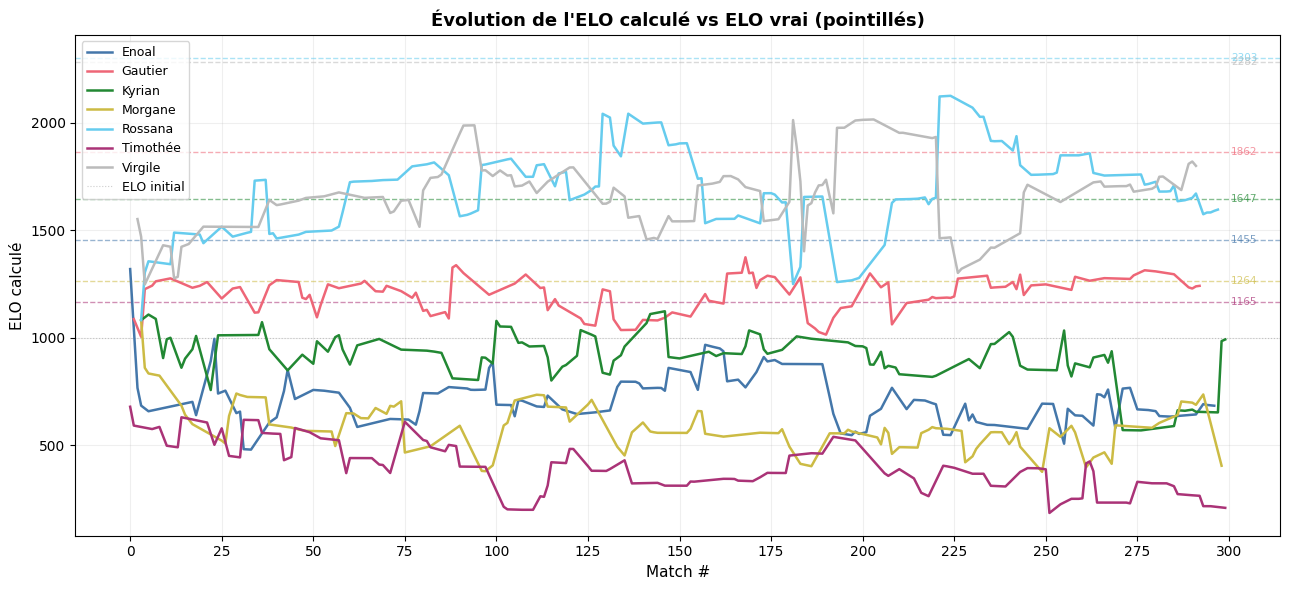

Figure sauvegardée : elo_evolution.png


In [68]:
# Couleurs colorblind-friendly (même palette que le front)
COLORS = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB"]

fig, ax = plt.subplots(figsize=(13, 6))

for idx, player in enumerate(PLAYERS):
    color = COLORS[idx % len(COLORS)]
    xs = [x for x, _ in history[player]]
    ys = [y for _, y in history[player]]

    ax.plot(xs, ys, color=color, linewidth=1.8, label=player, zorder=3)

    # Ligne horizontale de l'ELO vrai (pointillés)
    ax.axhline(TRUE_ELO[player], color=color, linestyle="--",
               linewidth=1, alpha=0.55, zorder=2)

    # Annotation de l'ELO vrai à droite
    ax.annotate(f"{TRUE_ELO[player]}",
                xy=(len(games) - 1, TRUE_ELO[player]),
                xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=7.5, color=color, alpha=0.7)

ax.axhline(INITIAL_ELO, color="gray", linestyle=":", linewidth=0.8, alpha=0.4, label="ELO initial")
ax.set_xlabel("Match #", fontsize=11)
ax.set_ylabel("ELO calculé", fontsize=11)
ax.set_title("Évolution de l'ELO calculé vs ELO vrai (pointillés)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
plt.tight_layout()
plt.savefig("elo_evolution.png", dpi=150)
plt.show()
print("Figure sauvegardée : elo_evolution.png")

## 6. 🎯 Convergence : écart |ELO calculé − ELO vrai| au fil du temps

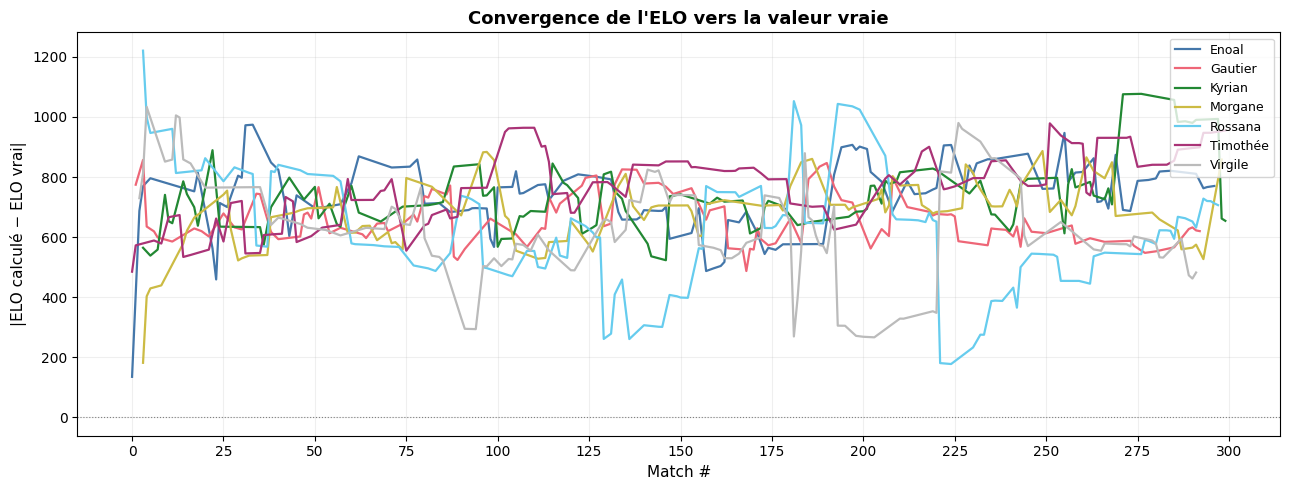

Figure sauvegardée : elo_convergence.png


In [69]:
fig, ax = plt.subplots(figsize=(13, 5))

for idx, player in enumerate(PLAYERS):
    color = COLORS[idx % len(COLORS)]
    entries = history[player]
    if not entries:
        continue

    xs = [x for x, _ in entries]
    diffs = [abs(y - TRUE_ELO[player]) for _, y in entries]
    ax.plot(xs, diffs, color=color, linewidth=1.6, label=player)

ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Match #", fontsize=11)
ax.set_ylabel("|ELO calculé − ELO vrai|", fontsize=11)
ax.set_title("Convergence de l'ELO vers la valeur vraie", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
plt.tight_layout()
plt.savefig("elo_convergence.png", dpi=150)
plt.show()
print("Figure sauvegardée : elo_convergence.png")

## 7. 🏅 Score final : classement calculé vs classement vrai

In [70]:
final_elos = {p: (history[p][-1][1] if history[p] else INITIAL_ELO) for p in PLAYERS}

rank_true = sorted(PLAYERS, key=lambda p: -TRUE_ELO[p])
rank_comp = sorted(PLAYERS, key=lambda p: -final_elos[p])

print(f"{'Rang':<6} {'Classement vrai':<18} {'Classement calculé':<18} {'ELO vrai':>9} {'ELO calc':>10} {'Diff':>7}")
print("-" * 72)
for r, (pt, pc) in enumerate(zip(rank_true, rank_comp), 1):
    match = "✅" if pt == pc else "❌"
    diff  = final_elos[pc] - TRUE_ELO[pc]
    print(f"{r:<6} {pt:<18} {pc:<18} {TRUE_ELO[pt]:>9} {final_elos[pc]:>10.1f} {diff:>+7.1f}  {match}")

# Correlation rang
from scipy.stats import spearmanr
true_ranks = [rank_true.index(p) for p in PLAYERS]
calc_ranks = [rank_comp.index(p) for p in PLAYERS]
rho, p_val = spearmanr(true_ranks, calc_ranks)
print(f"\nCorrelation de Spearman entre les classements : ρ = {rho:.3f} (p = {p_val:.4f})")

Rang   Classement vrai    Classement calculé  ELO vrai   ELO calc    Diff
------------------------------------------------------------------------
1      Rossana            Virgile                 2303     1799.8  -482.2  ❌
2      Virgile            Rossana                 2282     1596.5  -706.5  ❌
3      Gautier            Gautier                 1862     1242.0  -620.0  ✅
4      Kyrian             Kyrian                  1647      992.7  -654.3  ✅
5      Enoal              Enoal                   1455      684.7  -770.3  ✅
6      Morgane            Morgane                 1264      405.7  -858.3  ✅
7      Timothée           Timothée                1165      210.0  -955.0  ✅

Correlation de Spearman entre les classements : ρ = 0.964 (p = 0.0005)


## 8. 🔥 Impact du K adaptatif (kill streak)

On compare l'ELO final obtenu avec K fixe vs K adaptatif.

In [71]:
def compute_elo_fixed_k(games, k=K_BASE, players=PLAYERS):
    """Calcul ELO sans kill streak (K constant)."""
    current_elo = {p: INITIAL_ELO for p in players}
    history = {p: [] for p in players}

    for i, game in enumerate(games):
        pa, pb = game["players_a"], game["players_b"]
        for p in pa + pb:
            if p not in current_elo:
                current_elo[p] = INITIAL_ELO
                history[p] = []

        avg_a = sum(current_elo[p] for p in pa) / len(pa)
        avg_b = sum(current_elo[p] for p in pb) / len(pb)
        total = game["score_a"] + game["score_b"]

        def p_goal(elo_us, elo_them):
            return 1 / (1 + math.pow(10, ALPHA * (elo_them - elo_us)))

        for p in pa:
            exp = p_goal(avg_a, avg_b) * total
            current_elo[p] += k * (game["score_a"] - exp) / len(pa)
            history[p].append((i, current_elo[p]))

        for p in pb:
            exp = p_goal(avg_b, avg_a) * total
            current_elo[p] += k * (game["score_b"] - exp) / len(pb)
            history[p].append((i, current_elo[p]))

    return history


history_fixed, _ = compute_elo(games)  # adaptatif — same as above
history_flat     = compute_elo_fixed_k(games, k=K_BASE)

print(f"{'Joueur':<12} {'ELO vrai':>9} {'K adaptatif':>13} {'K fixe (32)':>13} {'Δ adapt-vrai':>14} {'Δ fixe-vrai':>13}")
print("-" * 66)
for p in PLAYERS:
    adapt = history[p][-1][1] if history[p] else INITIAL_ELO
    flat  = history_flat[p][-1][1] if history_flat[p] else INITIAL_ELO
    print(f"{p:<12} {TRUE_ELO[p]:>9} {adapt:>13.1f} {flat:>13.1f}  {adapt-TRUE_ELO[p]:>+13.1f}  {flat-TRUE_ELO[p]:>+12.1f}")

Joueur        ELO vrai   K adaptatif   K fixe (32)   Δ adapt-vrai   Δ fixe-vrai
------------------------------------------------------------------
Enoal             1455         684.7         673.7         -770.3        -781.3
Gautier           1862        1242.0        1221.4         -620.0        -640.6
Kyrian            1647         992.7        1013.7         -654.3        -633.3
Morgane           1264         405.7         499.7         -858.3        -764.3
Rossana           2303        1596.5        1657.4         -706.5        -645.6
Timothée          1165         210.0         229.5         -955.0        -935.5
Virgile           2282        1799.8        1704.5         -482.2        -577.5


## 9. 📊 Sensibilité — combien de matchs pour converger ?

On trace l'erreur quadratique moyenne (RMSE) entre ELO calculé et ELO vrai en fonction du nombre de matchs joués.

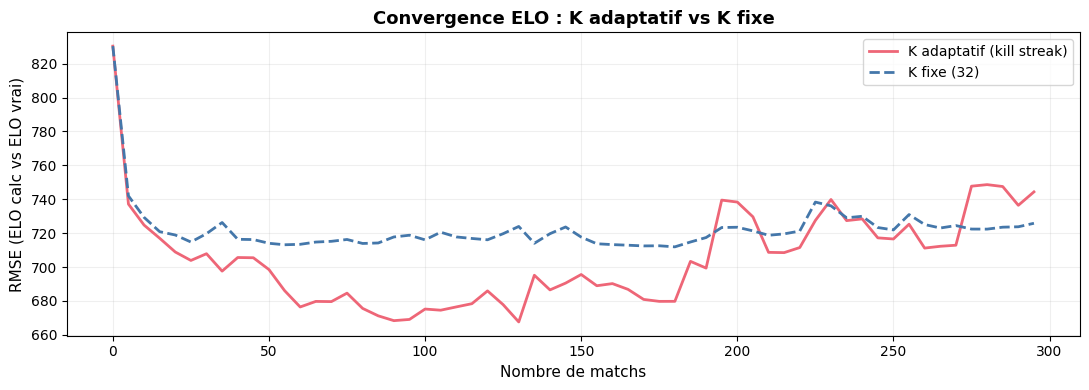

Figure sauvegardée : elo_rmse.png


In [72]:
def rmse_at(history, game_indices):
    """RMSE moyen sur tous les joueurs à chaque game_index donné."""
    rmse_list = []
    for gi in game_indices:
        sq_errors = []
        for p in PLAYERS:
            played = [(x, y) for x, y in history[p] if x <= gi]
            elo_est = played[-1][1] if played else INITIAL_ELO
            sq_errors.append((elo_est - TRUE_ELO[p]) ** 2)
        rmse_list.append(math.sqrt(sum(sq_errors) / len(sq_errors)))
    return rmse_list

xs = list(range(0, len(games), 5))
rmse_adapt = rmse_at(history, xs)
rmse_flat  = rmse_at(history_flat, xs)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(xs, rmse_adapt, color="#EE6677", linewidth=2, label="K adaptatif (kill streak)")
ax.plot(xs, rmse_flat,  color="#4477AA", linewidth=2, label="K fixe (32)", linestyle="--")
ax.set_xlabel("Nombre de matchs", fontsize=11)
ax.set_ylabel("RMSE (ELO calc vs ELO vrai)", fontsize=11)
ax.set_title("Convergence ELO : K adaptatif vs K fixe", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("elo_rmse.png", dpi=150)
plt.show()
print("Figure sauvegardée : elo_rmse.png")